## Notebook 05 — Multilayer Perceptron
**Project:** Machine Learning for High Performance Optical Sorting
**Author:** Mohamed Tawfeek
**Description:** MLP training, architecture and regularisation search, evaluation, and comparison against the Random Forest


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler

In [2]:
CLASSES = ['glass', 'paper', 'cardboard', 'plastic', 'metal', 'trash']
CLASS_ORDER = sorted(CLASSES)   # sklearn orders classes alphabetically
FEATURES_PATH = os.path.join('..', 'results', 'features')
RESULTS_PATH = os.path.join('..', 'results')
FIGURES_PATH = os.path.join('..', 'results', 'figures')

In [3]:
all_features = np.load(os.path.join(FEATURES_PATH, 'features.npy'))
all_labels = np.load(os.path.join(FEATURES_PATH, 'labels.npy'))

In [4]:
X_train_val, X_test, y_train_val, y_test = train_test_split(
    all_features, all_labels,
    test_size=0.15,
    random_state=42,
    stratify=all_labels
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val,
    test_size=0.176,
    random_state=42,
    stratify=y_train_val
)

print(f"\nTraining set:   {X_train.shape[0]} samples")
print(f"Validation set: {X_val.shape[0]} samples")
print(f"Test set:       {X_test.shape[0]} samples")


Training set:   1769 samples
Validation set: 378 samples
Test set:       380 samples


In [5]:
# Standardises features to zero mean and unit variance, which is required for stable MLP gradient-based optimisation

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print(f"Training set mean: {X_train_scaled.mean():.6f}")
print(f"Training set std: {X_train_scaled.std():.6f}")
print(f"Train shape: {X_train_scaled.shape}")
print(f"Val shape:   {X_val_scaled.shape}")
print(f"Test shape:  {X_test_scaled.shape}")

Training set mean: 0.000000
Training set std: 0.962408
Train shape: (1769, 122)
Val shape:   (378, 122)
Test shape:  (380, 122)


In [6]:
# Trains a single-hidden-layer MLP with default settings to establish an untuned baseline

mlp_default = MLPClassifier(
    hidden_layer_sizes = (100,),
    max_iter=500,
    random_state=42
)

mlp_default.fit(X_train_scaled, y_train)

val_accuracy = mlp_default.score(X_val_scaled, y_val)
print(f"Default MLP accuracy: {val_accuracy:.4f}")

Default MLP accuracy: 0.8228


In [7]:
# Cross-validates weighted F1 across several hidden layer size configurations to select the best architecture

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
architectures = [(50,), (100,), (200,), (100, 50), (100, 100)]
arch_scores = []

for arch in architectures:
    mlp = MLPClassifier(
        hidden_layer_sizes=arch,
        max_iter=500,
        random_state=42
    )
    scores = cross_val_score(mlp, X_train_scaled, y_train, cv=cv, scoring='f1_weighted')
    mean_score = scores.mean()
    arch_scores.append(mean_score)
    print(f"hidden_layer_sizes={str(arch):12} — Mean weighted F1: {mean_score:.4f} (+/- {scores.std():.4f})")

best_arch = architectures[np.argmax(arch_scores)]
print(f"\nBest architecture: {best_arch}")

C:\Users\Mohamed\miniconda3\envs\optical-sorting\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


C:\Users\Mohamed\miniconda3\envs\optical-sorting\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


C:\Users\Mohamed\miniconda3\envs\optical-sorting\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


hidden_layer_sizes=(50,)        — Mean weighted F1: 0.7557 (+/- 0.0220)


hidden_layer_sizes=(100,)       — Mean weighted F1: 0.7769 (+/- 0.0093)


hidden_layer_sizes=(200,)       — Mean weighted F1: 0.7836 (+/- 0.0142)


hidden_layer_sizes=(100, 50)    — Mean weighted F1: 0.7826 (+/- 0.0113)


hidden_layer_sizes=(100, 100)   — Mean weighted F1: 0.7686 (+/- 0.0208)

Best architecture: (200,)


In [8]:
# Cross-validates weighted F1 across L2 regularisation strengths with the best architecture fixed

alpha_options = [0.0001, 0.001, 0.01, 0.1]
alpha_scores = []

for alpha in alpha_options:
    mlp = MLPClassifier(
        hidden_layer_sizes=(200,),
        alpha=alpha,
        max_iter=1000,
        random_state=42
    )
    scores = cross_val_score(mlp, X_train_scaled, y_train, cv=cv, scoring='f1_weighted')
    mean_score = scores.mean()
    alpha_scores.append(mean_score)
    print(f"alpha={alpha:6} — Mean weighted F1: {mean_score:.4f} (+/- {scores.std():.4f})")

best_alpha = alpha_options[np.argmax(alpha_scores)]
print(f"\nBest alpha: {best_alpha}")

alpha=0.0001 — Mean weighted F1: 0.7836 (+/- 0.0142)


alpha= 0.001 — Mean weighted F1: 0.7847 (+/- 0.0120)


alpha=  0.01 — Mean weighted F1: 0.7829 (+/- 0.0056)


alpha=   0.1 — Mean weighted F1: 0.7852 (+/- 0.0090)

Best alpha: 0.1


In [9]:
# alpha=0.01 is kept over the CV-best 0.1: mean weighted F1 differs by only 0.0023
# while alpha=0.01 has the lowest fold-to-fold std (0.0056), making it the more
# stable setting under cross-validation.
mlp_final = MLPClassifier(
    hidden_layer_sizes=(200,),
    alpha=0.01,
    max_iter=1000,
    random_state=42
)

mlp_final.fit(X_train_scaled, y_train)

val_accuracy = mlp_final.score(X_val_scaled, y_val)
print(f"Final MLP — Validation accuracy: {val_accuracy:.4f}")

print(f"Number of iterations run: {mlp_final.n_iter_}")
print(f"Converged: {mlp_final.n_iter_ < 1000}")

Final MLP — Validation accuracy: 0.8201
Number of iterations run: 281
Converged: True


In [10]:
y_pred_mlp = mlp_final.predict(X_test_scaled)

print("=== MLP Test Set Results ===\n")
print(classification_report(y_test, y_pred_mlp, labels=CLASS_ORDER, target_names=CLASS_ORDER))

report_str = classification_report(y_test, y_pred_mlp, labels=CLASS_ORDER, target_names=CLASS_ORDER)
with open(os.path.join(RESULTS_PATH, 'mlp_classification_report.txt'), 'w') as f:
    f.write(report_str)

accuracy_mlp = mlp_final.score(X_test_scaled, y_test)
with open(os.path.join(RESULTS_PATH, 'mlp_accuracy.txt'), 'w') as f:
    f.write(str(accuracy_mlp))

print(f"Test accuracy: {accuracy_mlp:.4f}")
print("Results saved.")

=== MLP Test Set Results ===

              precision    recall  f1-score   support

   cardboard       0.90      0.87      0.88        61
       glass       0.76      0.73      0.75        75
       metal       0.69      0.76      0.72        62
       paper       0.86      0.87      0.86        89
     plastic       0.83      0.83      0.83        72
       trash       0.74      0.67      0.70        21

    accuracy                           0.81       380
   macro avg       0.80      0.79      0.79       380
weighted avg       0.81      0.81      0.81       380

Test accuracy: 0.8053
Results saved.


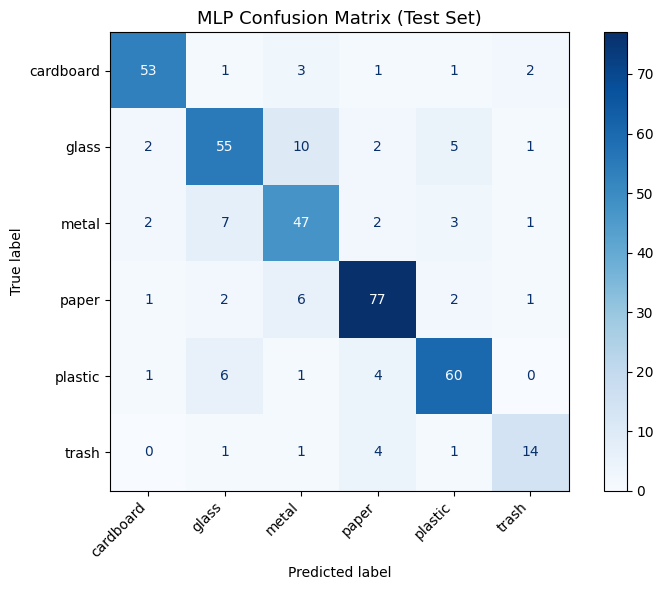

Confusion matrix saved.


In [11]:
cm_mlp = confusion_matrix(y_test, y_pred_mlp, labels=CLASS_ORDER)

fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_mlp, display_labels=CLASS_ORDER)
disp.plot(ax=ax, colorbar=True, cmap='Blues')

ax.set_title('MLP Confusion Matrix (Test Set)', fontsize=13)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

plt.savefig(os.path.join(FIGURES_PATH, 'mlp_confusion_matrix.png'), dpi=150)
np.save(os.path.join(RESULTS_PATH, 'mlp_confusion_matrix.npy'), cm_mlp)

plt.show()
print("Confusion matrix saved.")

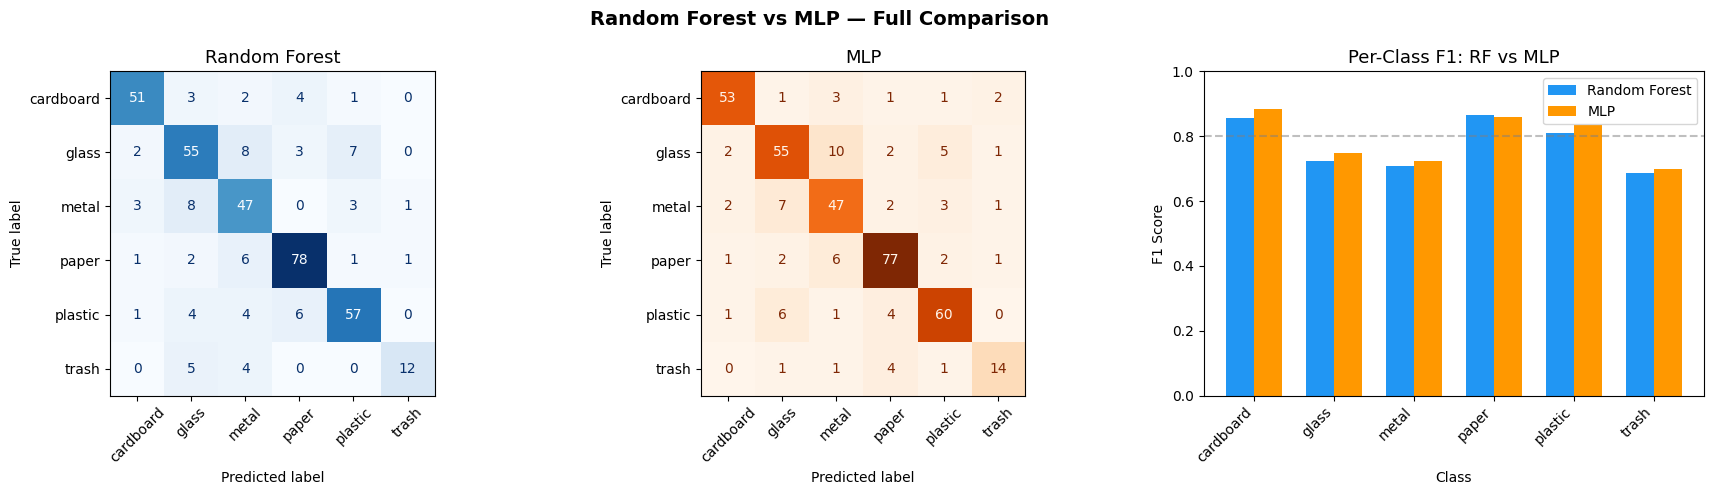

Comparison plot saved.


In [12]:
# Produces side-by-side confusion matrices and a per-class F1 bar chart comparing RF and MLP

cm_rf = np.load(os.path.join(RESULTS_PATH, 'rf_confusion_matrix.npy'))

def per_class_f1(cm):
    tp = np.diag(cm).astype(float)
    fp = cm.sum(axis=0) - tp
    fn = cm.sum(axis=1) - tp
    return 2 * tp / (2 * tp + fp + fn)

rf_f1  = per_class_f1(cm_rf)
mlp_f1 = per_class_f1(cm_mlp)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=CLASS_ORDER)
disp_rf.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Random Forest', fontsize=13)
axes[0].tick_params(axis='x', rotation=45)

disp_mlp = ConfusionMatrixDisplay(confusion_matrix=cm_mlp, display_labels=CLASS_ORDER)
disp_mlp.plot(ax=axes[1], colorbar=False, cmap='Oranges')
axes[1].set_title('MLP', fontsize=13)
axes[1].tick_params(axis='x', rotation=45)

x = np.arange(len(CLASS_ORDER))
width = 0.35

axes[2].bar(x - width/2, rf_f1, width, label='Random Forest', color='#2196F3')
axes[2].bar(x + width/2, mlp_f1, width, label='MLP', color='#FF9800')
axes[2].set_xlabel('Class')
axes[2].set_ylabel('F1 Score')
axes[2].set_title('Per-Class F1: RF vs MLP', fontsize=13)
axes[2].set_xticks(x)
axes[2].set_xticklabels(CLASS_ORDER, rotation=45, ha='right')
axes[2].set_ylim(0, 1.0)
axes[2].legend()
axes[2].axhline(y=0.8, color='grey', linestyle='--', alpha=0.5)

plt.suptitle('Random Forest vs MLP — Full Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_PATH, 'rf_vs_mlp_comparison.png'), dpi=150)
plt.show()
print("Comparison plot saved.")

In [13]:
import pickle

model_path = os.path.join(RESULTS_PATH, 'mlp_final_model.pkl')
with open(model_path, 'wb') as f:
    pickle.dump(mlp_final, f)

scaler_path = os.path.join(RESULTS_PATH, 'mlp_scaler.pkl')
with open(scaler_path, 'wb') as f:
    pickle.dump(scaler, f)

print("Model saved to results/mlp_final_model.pkl")
print("Scaler saved to results/mlp_scaler.pkl")

Model saved to results/mlp_final_model.pkl
Scaler saved to results/mlp_scaler.pkl
